In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# Load dataset
df = pd.read_csv("World_development_mesurement.csv")

In [3]:
df.shape

(2704, 25)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              2585 non-null   float64
 1   Business Tax Rate       1423 non-null   object 
 2   CO2 Emissions           2125 non-null   float64
 3   Country                 2704 non-null   object 
 4   Days to Start Business  1718 non-null   float64
 5   Ease of Business        185 non-null    float64
 6   Energy Usage            1785 non-null   float64
 7   GDP                     2494 non-null   object 
 8   Health Exp % GDP        2395 non-null   float64
 9   Health Exp/Capita       2395 non-null   object 
 10  Hours to do Tax         1416 non-null   float64
 11  Infant Mortality Rate   2444 non-null   float64
 12  Internet Usage          2531 non-null   float64
 13  Lending Interest        1880 non-null   float64
 14  Life Expectancy Female  2568 non-null   

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Birth Rate,2585.0,2.271489e-02,1.133843e-02,0.007,0.01300,2.000000e-02,3.100000e-02,5.300000e-02
CO2 Emissions,2125.0,1.423071e+05,6.159288e+05,7.000,1360.00000,8.529000e+03,5.910800e+04,8.286892e+06
Days to Start Business,1718.0,3.999942e+01,5.731859e+01,1.000,13.00000,2.600000e+01,4.500000e+01,6.940000e+02
Ease of Business,185.0,9.487568e+01,5.479191e+01,1.000,48.00000,9.400000e+01,1.420000e+02,1.890000e+02
Energy Usage,1785.0,7.723684e+04,2.599239e+05,8.000,3737.00000,1.433800e+04,4.185200e+04,2.727728e+06
Health Exp % GDP,2395.0,6.416952e-02,2.632460e-02,0.008,0.04600,6.100000e-02,7.900000e-02,2.250000e-01
Hours to do Tax,1416.0,3.020685e+02,2.732997e+02,12.000,156.00000,2.390000e+02,3.447500e+02,2.600000e+03
Infant Mortality Rate,2444.0,3.281301e-02,2.996760e-02,0.002,0.00900,2.000000e-02,5.300000e-02,1.410000e-01
Internet Usage,2531.0,2.397471e-01,2.601318e-01,0.000,0.00000,1.000000e-01,4.000000e-01,1.000000e+00
Lending Interest,1880.0,1.481027e-01,1.718291e-01,0.005,0.08000,1.200000e-01,1.730000e-01,4.965000e+00


Missing Values

In [6]:


df.isna().sum()


,0
Birth Rate,119
Business Tax Rate,1281
CO2 Emissions,579
Country,0
Days to Start Business,986
Ease of Business,2519
Energy Usage,919
GDP,210
Health Exp % GDP,309
Health Exp/Capita,309


In [7]:
df.duplicated().sum()

np.int64(0)

Unique Values

In [8]:
df["Country"].nunique()

208

Univariate Analysis → Histogram

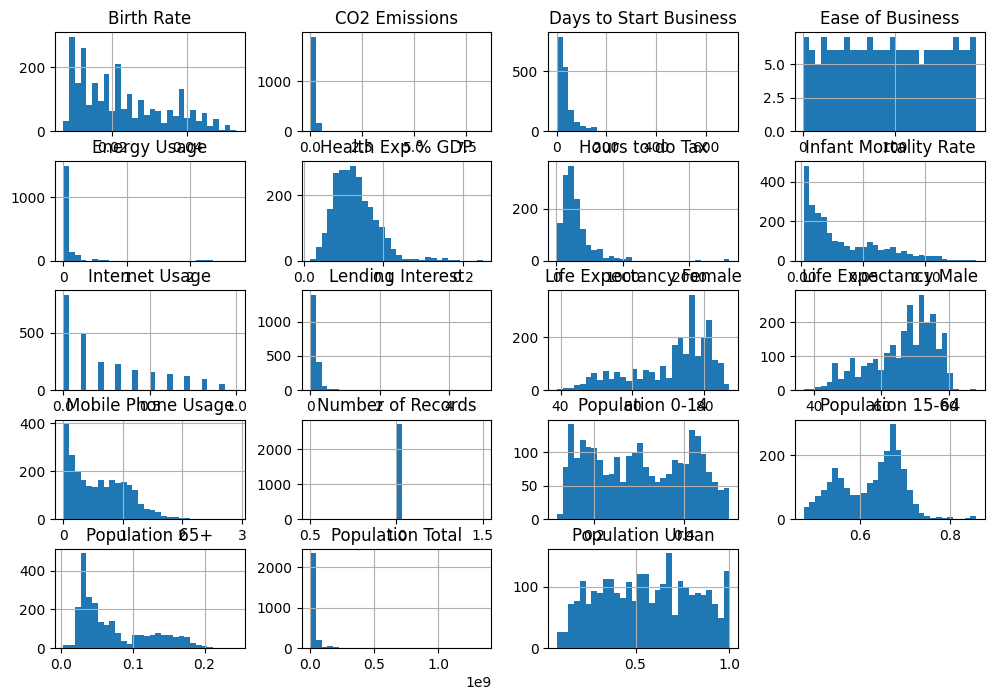

In [9]:
df.hist(figsize=(12, 8), bins=30)
plt.show()

Bivariate Analysis → Scatterplot

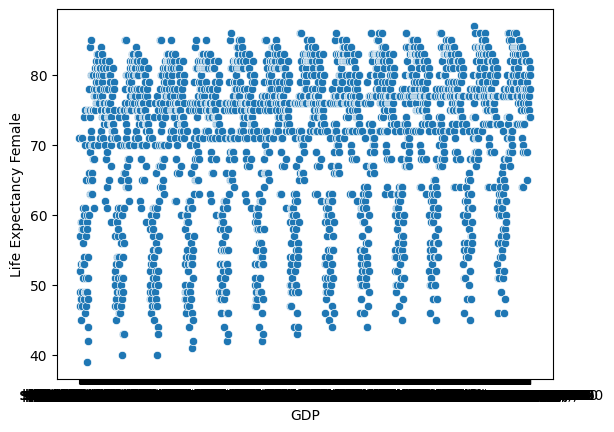

In [11]:
sns.scatterplot(data=df, x="GDP", y="Life Expectancy Female")
plt.show()

Correlation Matrix → Heatmap

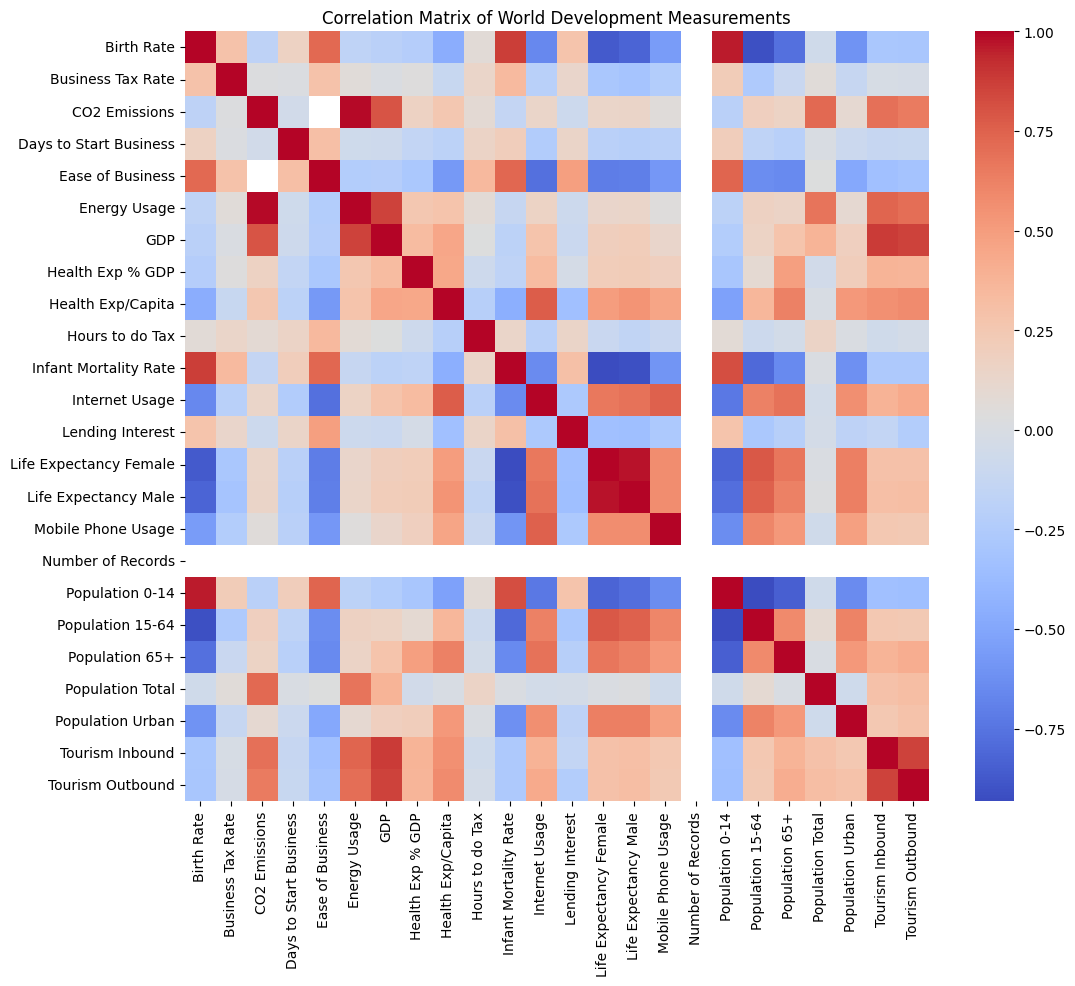

In [13]:
# Clean and convert columns with non-numeric characters to numeric
for col in ['Business Tax Rate', 'GDP', 'Health Exp/Capita', 'Tourism Inbound', 'Tourism Outbound']:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace('[$,%]', '', regex=True)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Calculate and plot the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title('Correlation Matrix of World Development Measurements')
plt.show()

Outlier Detection → Boxplot

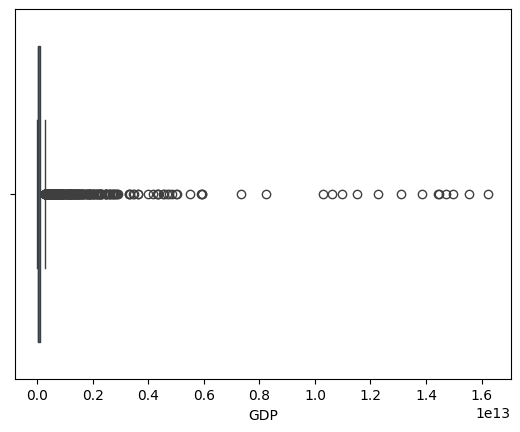

In [14]:
sns.boxplot(data=df, x="GDP")
plt.show()

In [16]:
df.skew(numeric_only=True)

,0
Birth Rate,0.662151
Business Tax Rate,4.342568
CO2 Emissions,8.654039
Days to Start Business,7.437592
Ease of Business,0.017745
Energy Usage,7.062230
GDP,9.424247
Health Exp % GDP,1.179757
Health Exp/Capita,2.817482
Hours to do Tax,4.491308


Missing Data Pattern

<Axes: >

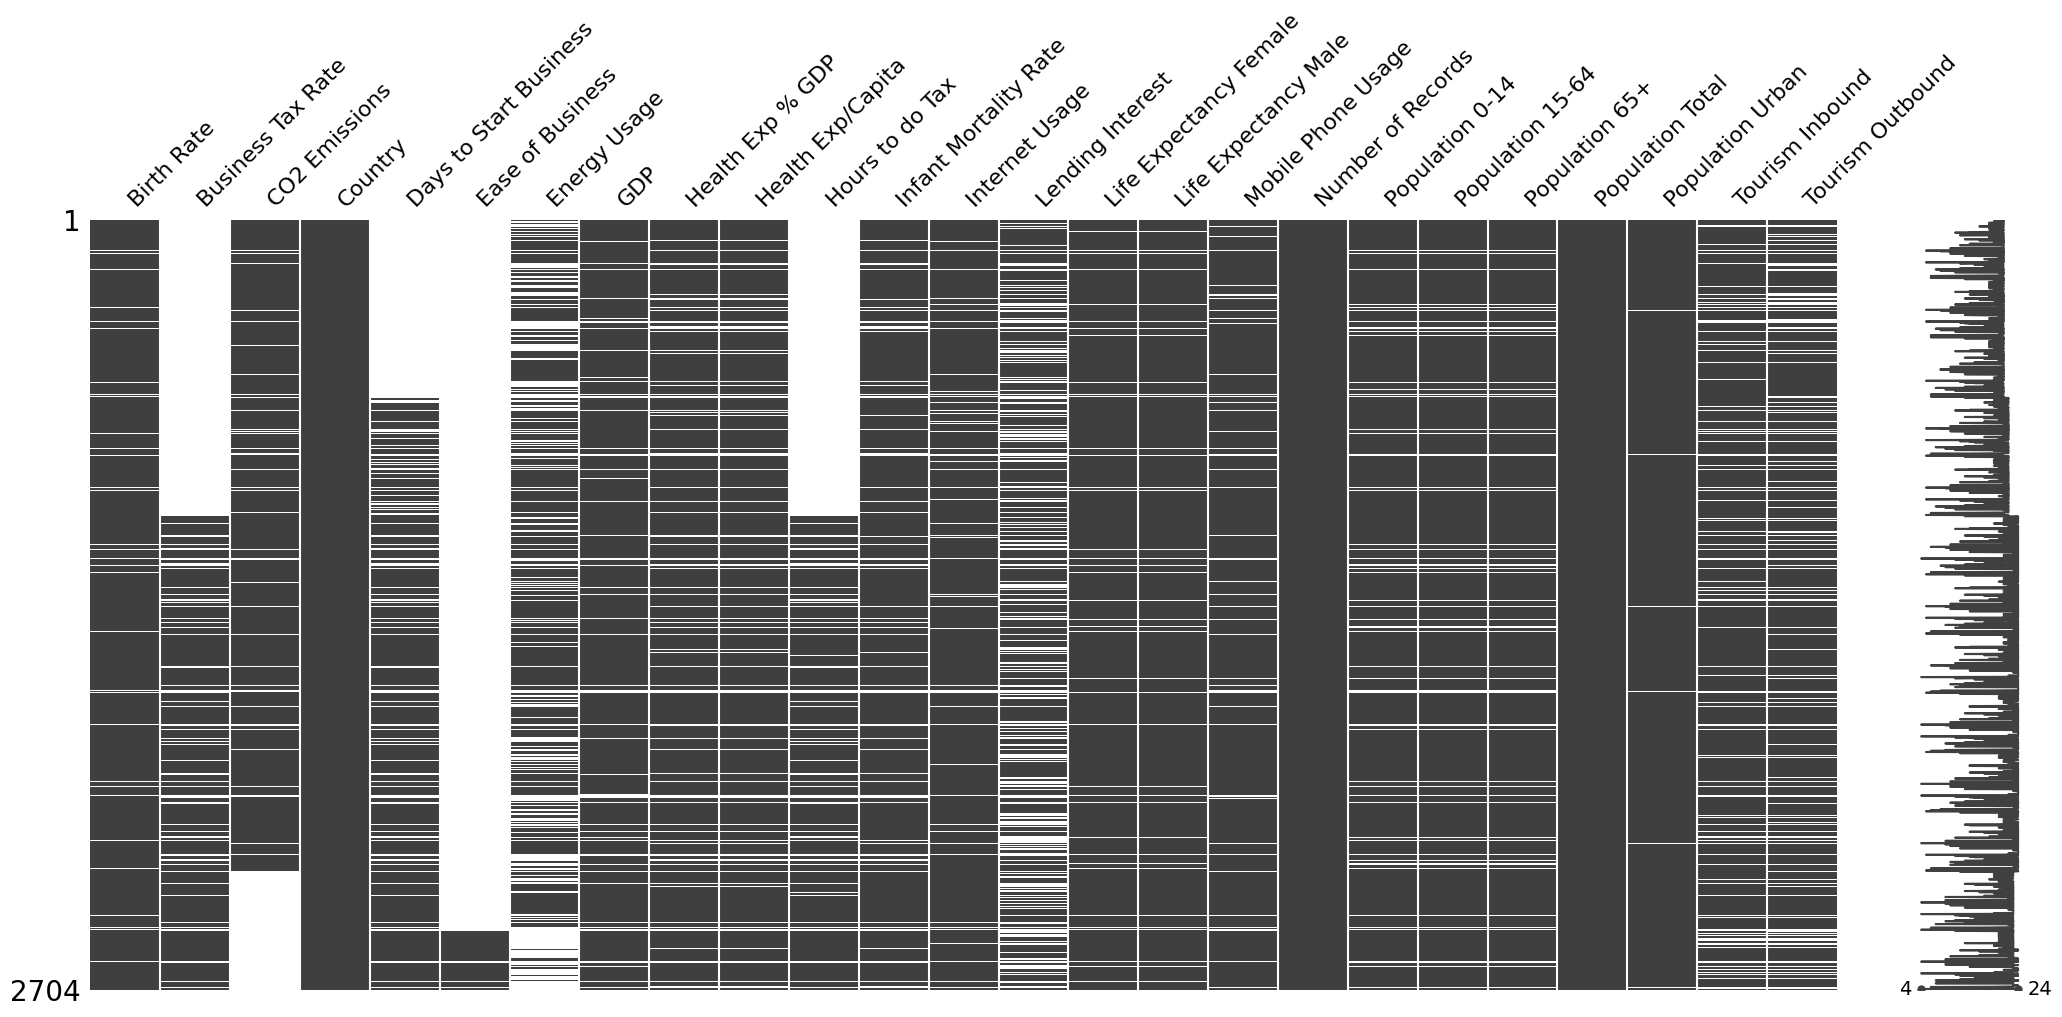

In [17]:
import missingno as msno
msno.matrix(df)

Country-wise Example (Top 10 GDP)

In [18]:
df.nlargest(10, "GDP")[["Country", "GDP"]]

,Country,GDP
2700,United States,1.624460e+13
2492,United States,1.553380e+13
2284,United States,1.495830e+13
1868,United States,1.472030e+13
1660,United States,1.448030e+13
2076,United States,1.441790e+13
1452,United States,1.385790e+13
1244,United States,1.309540e+13
1036,United States,1.227700e+13
828,United States,1.151220e+13


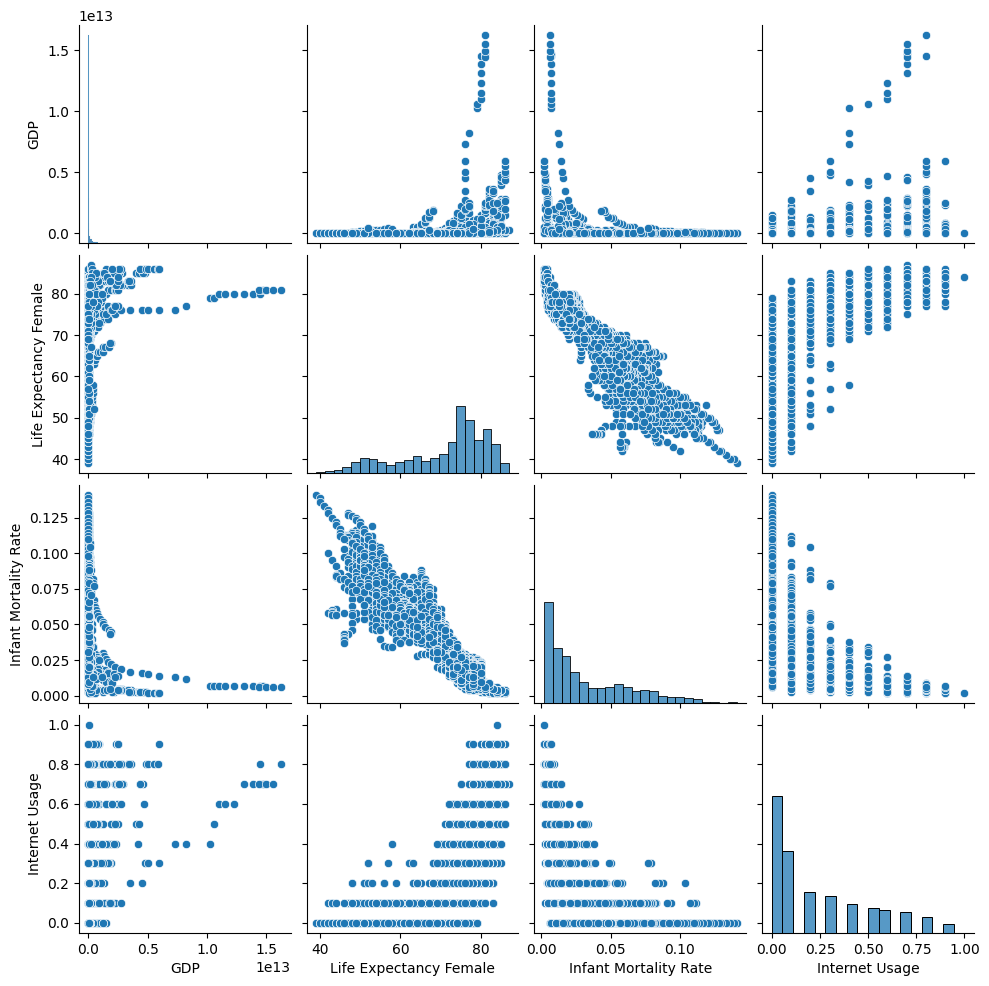

In [20]:
sns.pairplot(df[["GDP","Life Expectancy Female","Infant Mortality Rate","Internet Usage"]])
plt.show()